In [93]:
import numpy as np
from numpy import sqrt, zeros, ones, pi, linspace, sin, cos, tan
import matplotlib.pyplot as plt

### We wish to find the dispersions of electromagnetic modes supported by a metal-insulator interface (for which the metal has a nonlocal longitudinal permittivity). To this end, we use Eq. (11) of https://journals.aps.org/prb/pdf/10.1103/PhysRevB.88.115401 which we reiterate below: 

$\begin{align*}
1+\frac{\varepsilon_m\kappa_d}{\varepsilon_d \kappa_m} +\delta_{nl}=0\rightarrow  
1+\frac{\varepsilon_m\kappa_d}{\varepsilon_d \kappa_m} + \frac{k^2}{\kappa_{m} \kappa_{nl}}(\varepsilon_m-1),
\end{align*}$

where the local permittivity of the metal, $\varepsilon_m$, and the wavenumbers $\kappa_{m}$, $\kappa_d$, $\kappa_{nl}$ are given by the following expressions: 

$\begin{align*}
&\varepsilon_m(\omega) = 1-\frac{\omega_p^2}{\omega^2+i\omega\gamma}=1-\frac{1}{\Omega(\Omega+i\Gamma)}
\\& \kappa_m = \sqrt{k^2-\varepsilon_m(\omega/c)^2} = (\omega_p/c)\sqrt{K^2-\varepsilon_m\Omega^2}
\\& \kappa_d = \sqrt{k^2-\varepsilon_d(\omega/c)^2} = (\omega_p/c)\sqrt{K^2-\varepsilon_d\Omega^2}
\\&\kappa_{nl}=\sqrt{k^2-(\omega^2+i\gamma\omega-\omega_p^2)/\beta_F^2}=(\omega_p/c)\sqrt{K^2-(\Omega^2+i\Gamma\Omega-1)/\eta^2}
\end{align*}$

In [2]:
def return_epsilon_m(omega, gamma):
    return 1-1/(omega*(omega+1j*gamma))
def return_kappa_nl(k, omega, gamma, eta):
    return sqrt(k**2-(omega**2+1j*gamma*omega-1)/eta**2+ 0j)
def return_kappa_m(k, omega, gamma):
    return sqrt(k**2-return_epsilon_m(omega, gamma)*omega**2 + 0j)
def return_kappa_d(k, omega, epsilon_d):
    return sqrt(k**2-epsilon_d*omega**2+ 0j)

In [3]:
def equation_11(k, omega, gamma, eta, epsilon_d=1):
    epsilon_m = return_epsilon_m(omega, gamma)
    kappa_d = return_kappa_d(k, omega, epsilon_d)
    kappa_m = return_kappa_m(k, omega, gamma)
    kappa_nl = return_kappa_nl(k, omega, gamma, eta)

    kappa_d_real = kappa_d.real
    kappa_m_real = kappa_m.real
    kappa_nl_real = kappa_nl.real

    kappa_d = np.where(kappa_d_real < 0, -kappa_d, kappa_d)
    kappa_m = np.where(kappa_m_real < 0, -kappa_m, kappa_m)
    kappa_nl = np.where(kappa_nl_real < 0, -kappa_nl, kappa_nl)

    return 1 + (epsilon_m*kappa_d)/(epsilon_d*kappa_m)+(epsilon_m-1)/(kappa_m*kappa_nl)

In [67]:
eta = 5e-3
N_k_real = 1000
N_k_imag = 1000
#gamma = 0.1
gamma = 1e-3
N_omega = 250
k_v_real = np.linspace(0, 100, N_k_real)
#k_v_imag = np.linspace(0, 2, N_k_imag)
k_v_imag = np.linspace(0, 1, N_k_imag)
omega_v = np.linspace(0.5, 0.9, N_omega)
k_mat_real = np.repeat(np.reshape(k_v_real, (N_k_real, 1)), N_k_imag, axis=1)
k_mat_imag = np.repeat(np.reshape(k_v_imag, (1, N_k_imag)), N_k_real, axis=0)

In [68]:
dispersion_k_real = zeros(N_omega)
dispersion_k_imag = zeros(N_omega)
dispersion_mat = zeros((N_omega, N_k_real, N_k_imag), dtype=complex)
for (omega_idx, omega) in enumerate(omega_v):
    dispersion_relation = equation_11(k_mat_real + 1j*k_mat_imag, omega*ones((N_k_real, N_k_imag)), gamma, eta)
    row, col = np.unravel_index(np.argmin(np.abs(dispersion_relation)), (N_k_real, N_k_imag))
    dispersion_k_real[omega_idx] = k_v_real[row]
    dispersion_k_imag[omega_idx] = k_v_imag[col]
    dispersion_mat[omega_idx, :] = dispersion_relation

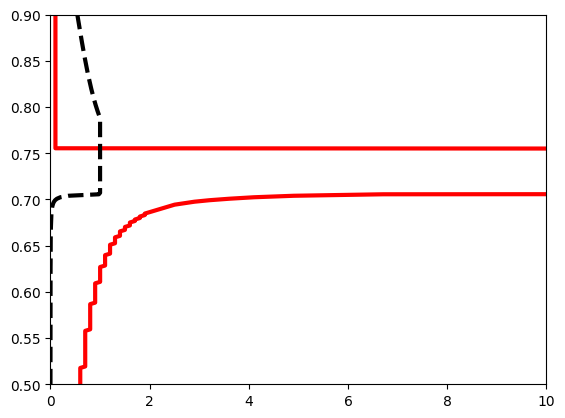

In [71]:
plt.plot(dispersion_k_real, omega_v, color="red", linewidth=3)
plt.plot(dispersion_k_imag, omega_v, linestyle="dashed", color="black", linewidth=3)
plt.ylim(0.5, 0.9)
plt.xlim(0, 10);

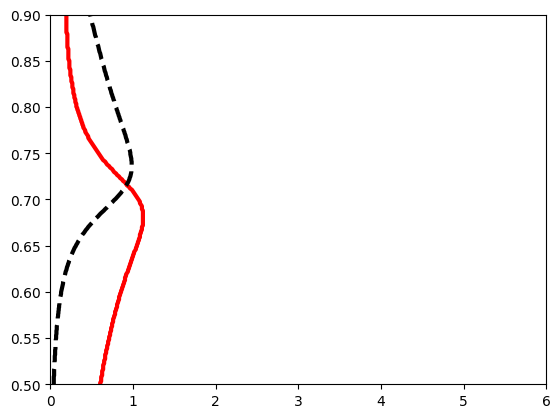

In [33]:
plt.plot(dispersion_k_real, omega_v, color="red", linewidth=3)
plt.plot(dispersion_k_imag, omega_v, linestyle="dashed", color="black", linewidth=3)
plt.ylim(0.5, 0.9)
plt.xlim(0, 6);

In [52]:
dispersion_mat_nonlocal = equation_11(k_mat, omega_mat, gamma, eta)
dispersion_mat_local = equation_11(k_mat, omega_mat, gamma, 1e-8)

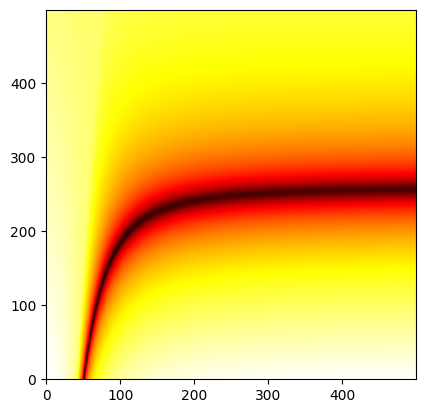

In [50]:
plt.imshow(np.log(np.abs(dispersion_mat_nonlocal)).T, cmap="hot", origin="lower")

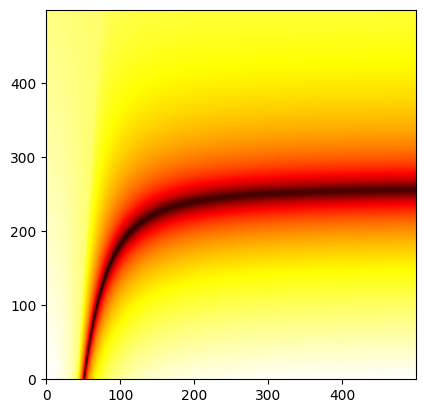

In [53]:
plt.imshow(np.log(np.abs(dispersion_mat_local)).T, cmap="hot", origin="lower")

### The code below reproduces (hopefully) figures 1 and 5 of the paper [Incoherent perfect absorption in lossy anisotropic materials](https://opg.optica.org/abstract.cfm?uri=oe-27-7-9561). Note that we define (in the notation of the linked paper) $\theta=\tan^{-1}(k_\tau/k_{n1})$, meaning $\theta$ is the angle from the  normal. For an isotropic medium, the absolute value of the p-polarized reflection coefficient will be given by the following:
$\begin{align*}
|r_p|=\Bigg|\frac{\varepsilon k_{n1}-k_{n2}}{\varepsilon k_{n1}+k_{n2}}\Bigg| = \Bigg|\frac{\varepsilon\cot(\theta)-\sqrt{\varepsilon\cot^2(\theta)+(\varepsilon-1)}}{\varepsilon\cot(\theta)+\sqrt{\varepsilon\cot^2(\theta)+(\varepsilon-1)}}\Bigg|=\Bigg|\frac{\varepsilon\cos(\theta)-\sqrt{\varepsilon-\sin^2(\theta)}}{\varepsilon\cos(\theta)+\sqrt{\varepsilon-\sin^2(\theta)}}\Bigg|
\end{align*}$,

where we used the following:

$\begin{align*}
&k_{n2}=\sqrt{\varepsilon(\omega/c)^2-k_\tau^2}=\sqrt{\varepsilon\Big[(\omega/c)^2-k_\tau^2 \Big]+(\varepsilon-1)k_\tau^2}
\\&=k_\tau\sqrt{\varepsilon k_{n1}^2/k_\tau^2+(\varepsilon-1)}=k_\tau\sqrt{\varepsilon\cot^2(\theta)+(\varepsilon-1)}
\end{align*}$

Note that requiring the reflection coefficient to vanish immediately gives us the Brewster angle:

$\varepsilon^2-\sin^2(\theta)\varepsilon^2=\varepsilon-\sin^2(\theta)\rightarrow \varepsilon(\varepsilon-1)=\sin^2(\theta)(\varepsilon^2-1)\rightarrow \sin^2(\theta)=\varepsilon/(\varepsilon+1)$, $\cos^2(\theta)=1/(\varepsilon+1), \tan^2(\theta)=\varepsilon$

In [113]:
def r_p(epsilon, theta):
    numerator = epsilon*cos(theta)-sqrt(epsilon-sin(theta)**2)
    denominator = epsilon*cos(theta)+sqrt(epsilon-sin(theta)**2)
    return np.abs(numerator/denominator)

In [114]:
N = 1000
angles = np.linspace(0, 90, N)
r_p_v_no_loss = r_p(2, angles*pi/180)
r_p_v_with_loss = r_p(2+2j, angles*pi/180)

### Below is Figure 1 of the Narimanov paper

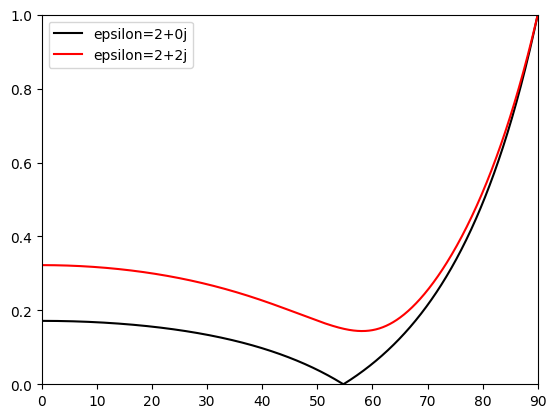

In [115]:
plt.plot(angles, r_p_v_no_loss, color="black", label="epsilon=2+0j")
plt.plot(angles, r_p_v_with_loss, color="red", label="epsilon=2+2j")
plt.ylim(0, 1)
plt.xlim(0, 90)
plt.legend();

In [117]:
brewster_angle = angles[np.argmin(r_p_v_no_loss)]
print("Brewster angle (in degrees): ", brewster_angle)

Brewster angle (in degrees):  54.77477477477477


### Now we move on to anisotropic materials. In this case, the absolute value of the reflection coefficient is given by the following (again, in the notation of the Narimanov paper):

$\begin{align*}
|r_p| = \Bigg|\frac{k_{1n}\varepsilon_{2\tau}-k_{2n}}{k_{1n}\varepsilon_{2\tau}+k_{2n}}\Bigg|=\Bigg|\frac{\varepsilon_{2\tau}\cot(\theta)-k_{2n}/k_\tau}{\varepsilon_{2\tau}\cot(\theta)+k_{2n}/k_\tau} \Bigg|
\end{align*}$,

where $k_{2n}$ is given by the following expression:

$\begin{align*}
k_{2n}=\sqrt{\varepsilon_{2\tau}(\omega/c)^2-(\varepsilon_{2\tau}/\varepsilon_{2n})k_\tau^2}=\sqrt{\varepsilon_{2\tau}\Big[(\omega/c)^2-k_\tau^2\Big]+\varepsilon_{2\tau}\Big[1-1/\varepsilon_{2n}\Big]k_\tau^2}=k_\tau\sqrt{\varepsilon_{2\tau}\cot^2(\theta)+\varepsilon_{2\tau}(1-1/\varepsilon_{2n})}
\end{align*}$

In [118]:
def r_p_anisotropic(epsilon_tau, epsilon_n, theta):
    numerator = epsilon_tau/tan(theta)-sqrt(epsilon_tau/tan(theta)**2+epsilon_tau*(1-1/epsilon_n))
    denominator = epsilon_tau/tan(theta)+sqrt(epsilon_tau/tan(theta)**2+epsilon_tau*(1-1/epsilon_n))
    return np.abs(numerator/denominator)

### First we check that this reduces to the isotropic case for $\varepsilon_{2n}=\varepsilon_{2n}$

In [119]:
N = 1000
angles = np.linspace(0.0001, 90-0.0001, N)
r_p_v_no_loss = r_p_anisotropic(2, 2, angles*pi/180)

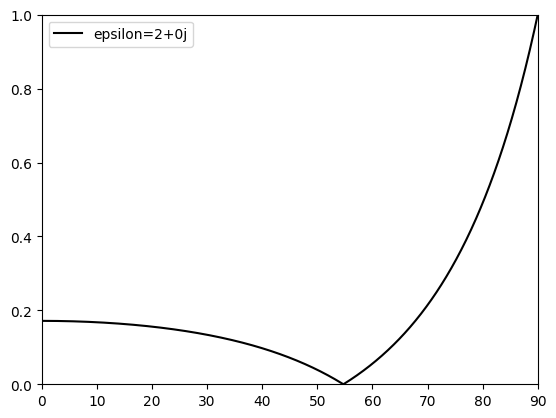

In [120]:
plt.plot(angles, r_p_v_no_loss, color="black", label="epsilon=2+0j")
plt.ylim(0, 1)
plt.xlim(0, 90)
plt.legend();

### Now we check for hBN for the two values of the permittivity given in Section 5 of the Narimanov paper: 

In [132]:
epsilon_n_1 = 7.351 + 0.038j
epsilon_tau_1 = 6.794 + 0.0047j

epsilon_n_2 = 3.051 + 0.0159j
epsilon_tau_2 = 8.084 + 0.0180j

In [134]:
N = 10000
angles = np.linspace(0.0001, 90-0.0001, N)
r_p_v_hbn_1 = r_p_anisotropic(epsilon_tau_1, epsilon_n_1, angles*pi/180)
r_p_v_hbn_2 = r_p_anisotropic(epsilon_tau_2, epsilon_n_2, angles*pi/180)

### Below is Figure 5 of the Narimanov paper

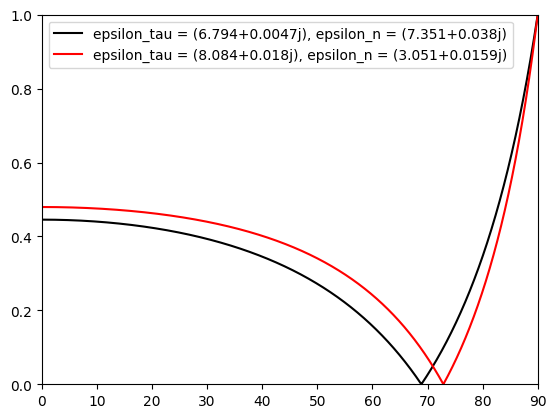

In [135]:
plt.plot(angles, r_p_v_hbn_1, color="black", label=f"epsilon_tau = {epsilon_tau_1}, epsilon_n = {epsilon_n_1}")
plt.plot(angles, r_p_v_hbn_2, color="red", label=f"epsilon_tau = {epsilon_tau_2}, epsilon_n = {epsilon_n_2}")

plt.ylim(0, 1)
plt.xlim(0, 90)
plt.legend();

In [126]:
brewster_angle_hbn_1 = angles[np.argmin(r_p_v_hbn_1)]
print("Brewster angle (in degrees): ", brewster_angle_hbn_1)

Brewster angle (in degrees):  68.88383531353136
